In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import json  # ✅ FIX: dùng json.loads thay vì ast.literal_eval

# Load rules
rules = pd.read_csv("/home/jovyan/work/delta_lake/gold/association_rules.csv")

# ✅ FIX: parse JSON string thay vì Python literal
rules["antecedent"] = rules["antecedent"].apply(json.loads)
rules["consequent"] = rules["consequent"].apply(json.loads)

# Build graph
G = nx.DiGraph()

for _, row in rules.iterrows():
    for ant in row["antecedent"]:
        for con in row["consequent"]:
            G.add_edge(ant, con,
                       weight=row["lift"],
                       confidence=row["confidence"])

print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")

degree = sorted(G.degree(), key=lambda x: x[1], reverse=True)
print("\nTop 10 most connected categories:")
for cat, deg in degree[:10]:
    print(f"  {cat}: {deg} connections")

Nodes: 14
Edges: 29

Top 10 most connected categories:
  bed_bath_table: 9 connections
  housewares: 8 connections
  furniture_decor: 8 connections
  baby: 6 connections
  health_beauty: 5 connections
  garden_tools: 5 connections
  sports_leisure: 4 connections
  cool_stuff: 3 connections
  toys: 2 connections
  computers_accessories: 2 connections


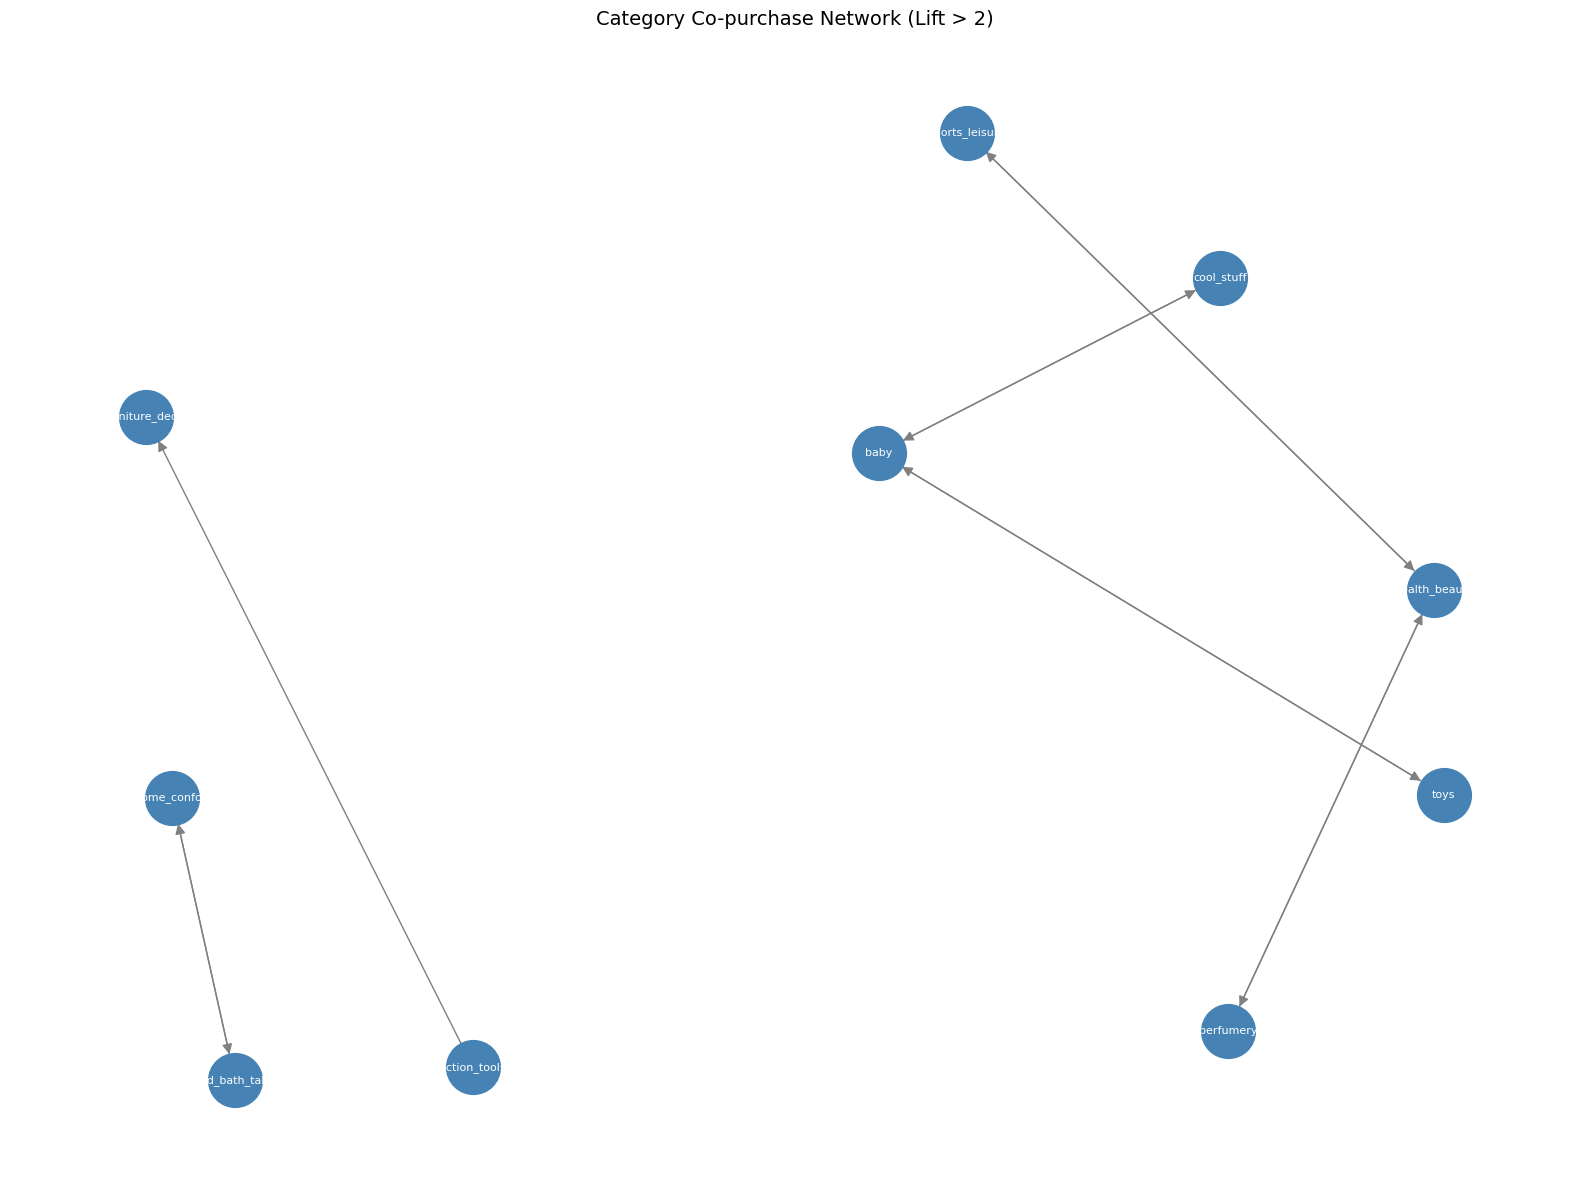

In [5]:
# Visualize
plt.figure(figsize=(16, 12))

# Chỉ lấy strong rules (lift > 2) để graph không quá rối
strong_edges = [(u, v) for u, v, d in G.edges(data=True) if d["weight"] > 2]
G_strong = G.edge_subgraph(strong_edges)

pos = nx.spring_layout(G_strong, seed=42, k=2)
nx.draw_networkx(
    G_strong, pos,
    node_size=1500,
    node_color="steelblue",
    font_size=8,
    font_color="white",
    edge_color="gray",
    arrows=True,
    arrowsize=15,
)
plt.title("Category Co-purchase Network (Lift > 2)", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.savefig("/home/jovyan/work/delta_lake/gold/network_graph.png", dpi=150)
plt.show()

In [8]:
# Export JSON đúng format cho frontend
pagerank = nx.pagerank(G)  # ✅ tính trên toàn bộ G

nodes = [{"id": node, "degree": G.degree(node),       # ✅ G thay vì G_strong
          "pagerank": round(pagerank[node], 4)} 
         for node in G.nodes()]

links = [{"source": u, "target": v, 
          "lift": round(d["weight"], 4),
          "confidence": round(d["confidence"], 4)} 
         for u, v, d in G.edges(data=True)]             # ✅ G thay vì G_strong

graph_data = {"nodes": nodes, "links": links}

with open("/home/jovyan/work/delta_lake/gold/network_graph.json", "w") as f:
    json.dump(graph_data, f, indent=2)

print("Saved network_graph.json")

Saved network_graph.json
